In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pickle

from sv3.nn import SvenWrapper, MLP
from sv3.sven import Sven

import sys
sys.path.append('../..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False,
    'mathtext.fontset': 'cm',
})

# Output directory for plots
PLOT_DIR = Path('plots/mnist/')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda
Plots will be saved to: /n/home11/sambt/iaifi/sv3/claude_experiments/microbatch_experiments/plots/mnist


In [11]:
LOADER_SEED = 292501
MODEL_SEED = 63644
DATA_SEED = 710931
batch_size = 128
microbatch_sizes = [1,2,4,8,16,32,64,128]
K = 128
lr_svd = 100.0
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-2
mlp_kwargs = {
    "input_dim": 784,
    "hidden_dims": [32,32,32],
    "output_dim": 10
}
standard_optimizers = ['Adam','SGD','RMSprop']

In [4]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset(ROOT='../../notebooks/datasets/')
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [8]:
set_seed(MODEL_SEED)
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### load in results from scan

### Baseline trainings

In [ ]:
device = 'cuda'
new_rows = []
for opt_name in standard_optimizers:
    #if lr_standard in df_baseline[df_baseline['optimizer'] == opt_name].lr.values:
    #    continue
    lr_standard = 1e-3 if opt_name != 'SGD' else 0.1
    print(f"Running standard training with optimizer: {opt_name}, lr: {lr_standard}")
    model_standard = MLP(**mlp_kwargs)
    model_standard.load_state_dict(init_state)
    model_standard = model_standard.to(device)

    opt = getattr(torch.optim, opt_name)
    optimizer = opt(model_standard.parameters(), lr=lr_standard if opt_name != 'SGD' else lr_svd)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_standard, losses = train_loop_standard(model_standard, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

    new_row = {
        'optimizer': opt_name,
        'lr': lr_standard,
        'batch_size': batch_size,
        'losses': losses}
    new_rows.append(new_row)
#df_baseline = pd.concat([df_baseline, pd.DataFrame(new_rows)], ignore_index=True)
df_baseline = pd.DataFrame(new_rows)

Running standard training with optimizer: Adam, lr: 0.001
Using device cuda


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:59<00:00,  3.00s/it]


Running standard training with optimizer: SGD, lr: 0.1
Using device cuda


100%|██████████| 20/20 [00:59<00:00,  2.95s/it]


Running standard training with optimizer: RMSprop, lr: 0.001
Using device cuda


100%|██████████| 20/20 [00:59<00:00,  2.95s/it]


### SVD training with varying microbatch

In [12]:
#if device == torch.device('mps'):
#    device = 'cpu'  # SVD optimizer not supported on MPS
device = 'cuda'
svd_info = {}
losses_svd = {}
for microbatch_size in microbatch_sizes:
    print("Running for microbatch size:", microbatch_size)
    model_svd = MLP(**mlp_kwargs)
    model_svd.load_state_dict(init_state)
    model_svd = model_svd.to(device)

    def loss_fn(pred,y):
        loss = nn.CrossEntropyLoss(reduction='none')(pred,y).squeeze()
        return loss

    model_svd = SvenWrapper(model_svd, loss_fn, microbatch_size=microbatch_size, device=device)
    optimizer = Sven(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True,svd_mode='randomized',use_rmsprop=True)


    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
    svd_info[microbatch_size] = optimizer.svd_info
    losses_svd[microbatch_size] = losses_run

    torch.compiler.reset()

Running for microbatch size: 1


  0%|          | 0/20 [00:00<?, ?it/s]

/n/home11/sambt/.conda/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1744: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [02:45<00:00,  8.28s/it]


Running for microbatch size: 2


100%|██████████| 20/20 [01:49<00:00,  5.46s/it]


...

  0%|          | 0/20 [00:00<?, ?it/s]/n/home11/sambt/.conda/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1744: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [01:17<00:00,  3.85s/it]


Running for microbatch size: 64


  0%|          | 0/20 [00:00<?, ?it/s]/n/home11/sambt/.conda/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1744: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [01:11<00:00,  3.56s/it]


Running for microbatch size: 128


  0%|          | 0/20 [00:00<?, ?it/s]/n/home11/sambt/.conda/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1744: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [01:06<00:00,  3.32s/it]


### Make plots

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

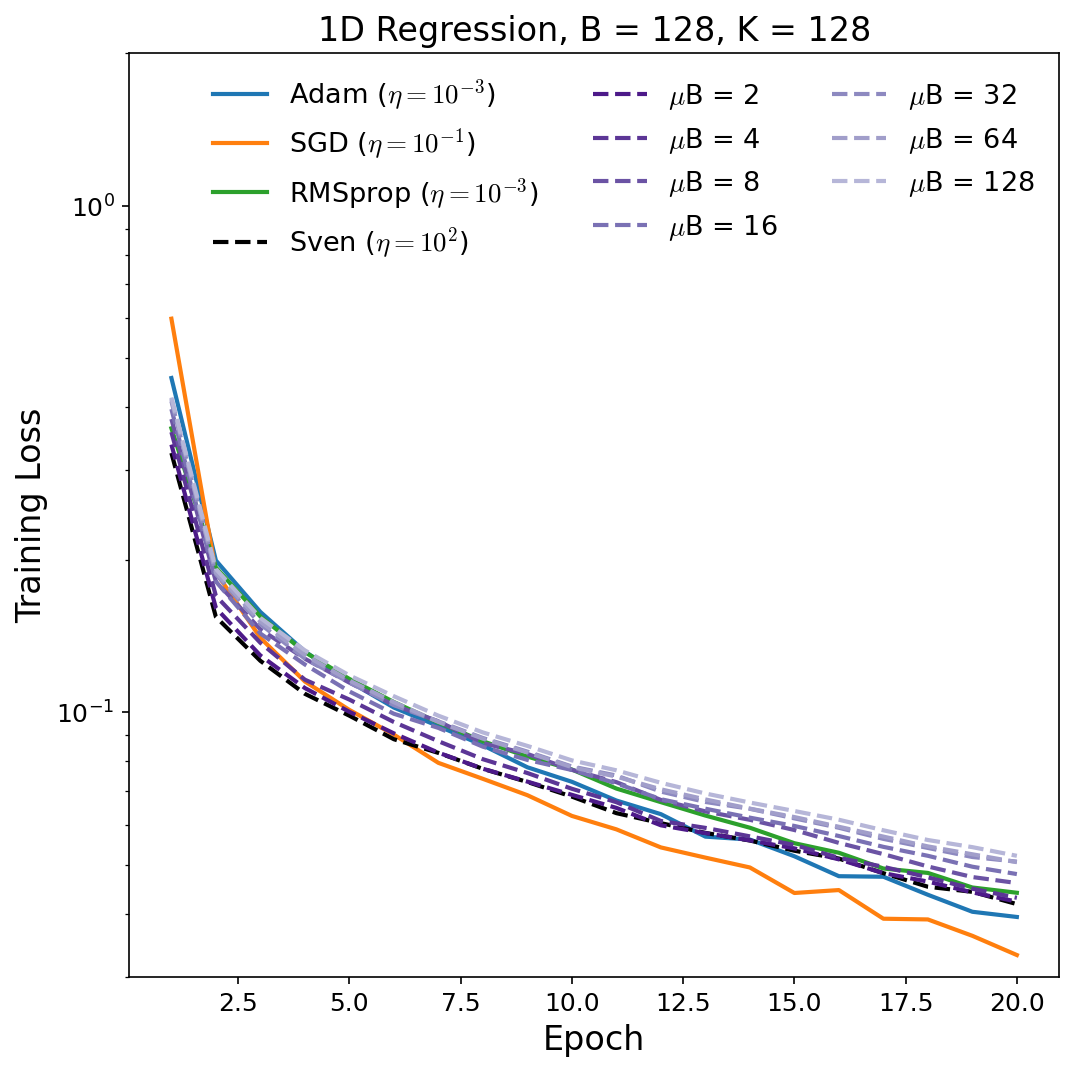

In [17]:
fig, ax = plt.subplots(figsize=(8,8))

LR_BASELINE = 1e-3
for i,opt in enumerate(standard_optimizers):
    df_sel = df_baseline[df_baseline['lr'] == LR_BASELINE] if opt != "SGD" else df_baseline[df_baseline['lr'] == 0.1]
    x = np.arange(1,21)
    y = df_sel[df_sel['optimizer'] == opt]['losses'].iloc[0]['train']
    ax.plot(x,y,f'C{i}-', label=f'{opt} ($\\eta=10^{{{int(np.log10(LR_BASELINE)) if opt != "SGD" else int(np.log10(0.1))}}}$)')

cmap = plt.get_cmap('Purples')
for i, mb in enumerate(microbatch_sizes):
    col_frac = 0.4 + 0.6*((len(microbatch_sizes)-1-i)/ (len(microbatch_sizes)-1))
    col = cmap(col_frac)
    #col = cmap(0.3 + 0.7 * (i / (len(microbatch_sizes) - 1)))
    if mb == 1:
        col = 'k'
    label = rf'$\mu$B = {mb}' if mb > 1 else f'Sven ($\\eta=10^{{{int(np.log10(lr_svd))}}}$)'
    x = np.arange(1,21)
    ax.plot(x, losses_svd[mb]['train'], 
            color=col, label=label, linestyle='--')
    
ax.set_title(f"1D Regression, B = {batch_size}, K = {K}")
ax.set_ylabel("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(3e-2, 2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3,fontsize=13)
plt.savefig(PLOT_DIR / f"train_loss_1d_regression_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")

NameError: name 'losses_standard' is not defined

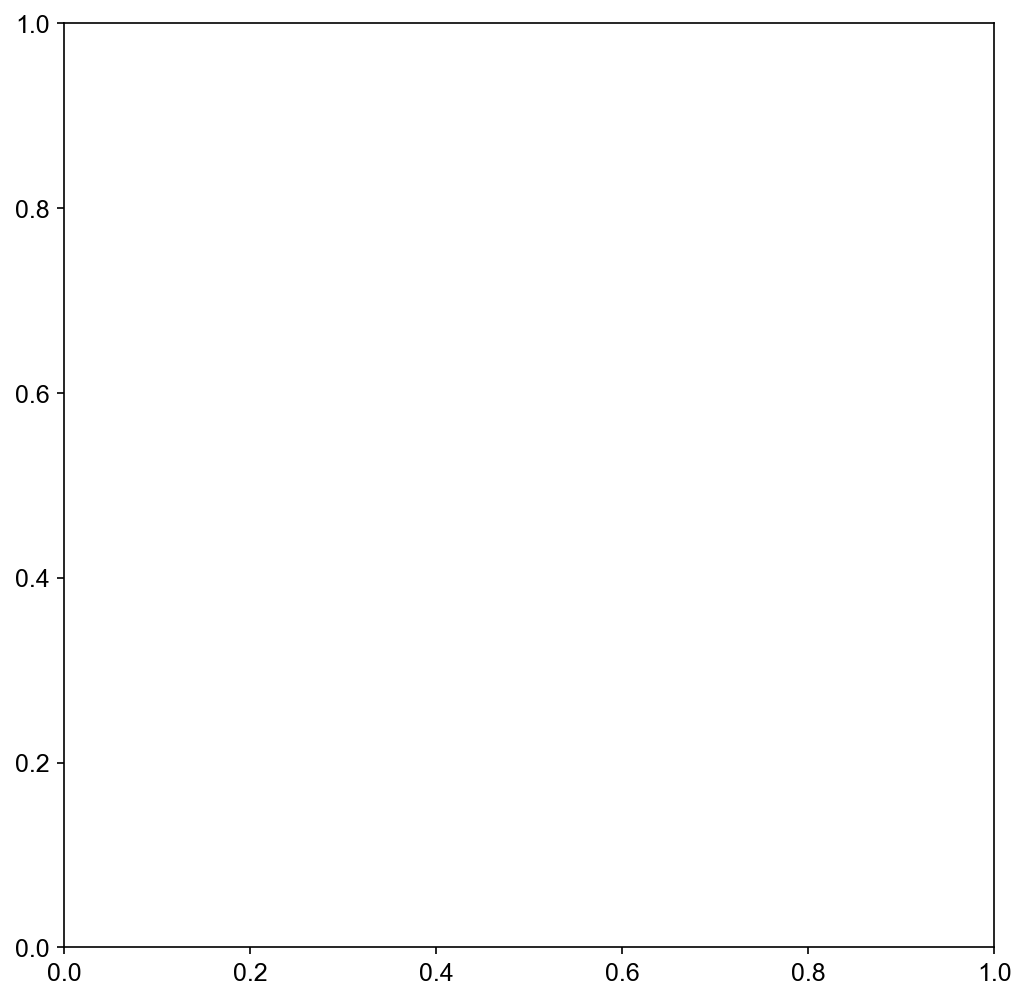

In [89]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(len(losses_standard[opt]['val'])), losses_standard[opt]['val'], f'C{i}-', label=f'{opt}')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'SVD, $\mu$B = {mb}' if mb > 1 else 'SVD'
    ax.plot(np.arange(len(losses_svd[mb]['val'])), losses_svd[mb]['val'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"bs = {batch_size}")
ax.set_ylabel("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-8, 1e2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3)
plt.savefig(PLOT_DIR / f"val_loss_1d_regression_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")